In [1]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits

%matplotlib notebook


In [2]:
ls data/SB41378

vela_a112_k16_spi32_ps_b0_b07_c01+f1.fits
vela_a112_k16_spi32_ps_b0_b07_c01+f2.fits
vela_a112_k16_spi32_ps_b0_b07_c01+f3.fits
vela_a112_k16_spi32_ps_b0_b07_c01+f4.fits
vela_a112_k16_spi32_ps_b0_b07_c01+f5.fits
vela_a112_k16_spi32_ps_b0_b07_c01+f6.fits
vela_a112_k16_spi32_ps_b0_b07_c02+f1.fits
vela_a112_k16_spi32_ps_b0_b07_c02+f2.fits
vela_a112_k16_spi32_ps_b0_b07_c02+f3.fits
vela_a112_k16_spi32_ps_b0_b07_c02+f4.fits
vela_a112_k16_spi32_ps_b0_b07_c02+f5.fits
vela_a112_k16_spi32_ps_b0_b07_c02+f6.fits
vela_a112_k16_spi32_ps_b0_b07_c03+f1.fits
vela_a112_k16_spi32_ps_b0_b07_c03+f2.fits
vela_a112_k16_spi32_ps_b0_b07_c03+f3.fits
vela_a112_k16_spi32_ps_b0_b07_c03+f4.fits
vela_a112_k16_spi32_ps_b0_b07_c03+f5.fits
vela_a112_k16_spi32_ps_b0_b07_c03+f6.fits
vela_a112_k16_spi32_ps_b0_b07_c04+f1.fits
vela_a112_k16_spi32_ps_b0_b07_c04+f2.fits
vela_a112_k16_spi32_ps_b0_b07_c04+f3.fits
vela_a112_k16_spi32_ps_b0_b07_c04+f4.fits
vela_a112_k16_spi32_ps_b0_b07_c04+f5.fits
vela_a112_k16_spi32_ps_b0_b07_c04+

In [3]:
p = CardcapFile('data/SB41378/vela_a112_k16_spi32_ps_b0_b07_c01+f6.fits')
# p = CardcapFile('data/SB41378/vela_a112_k16_spi32_ps_b0_b07_c01+f6.fits')

In [4]:
pkts = p.load_packets()

<IPython.core.display.Javascript object>


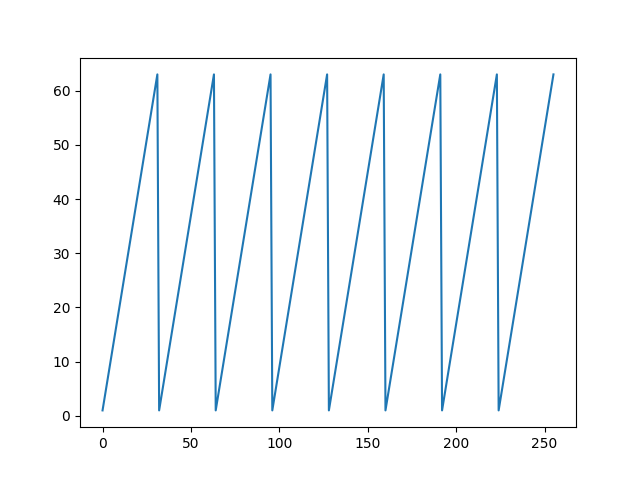

In [5]:
figure()
plot(pkts['sample_number'][:256])

<IPython.core.display.Javascript object>


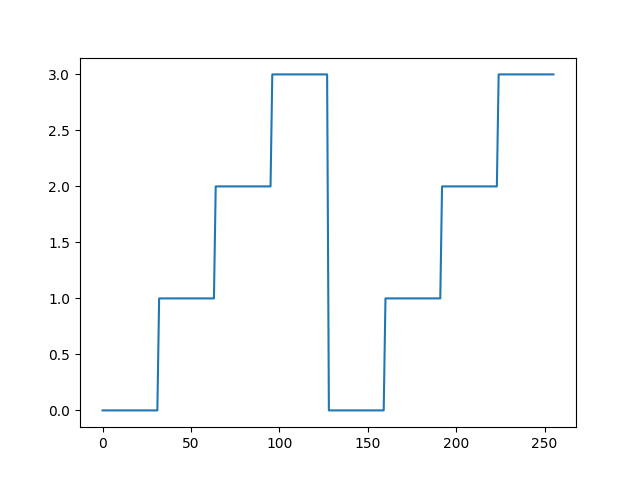

In [6]:
figure()
plot(pkts['channel_number'][:256])

In [7]:
pkts['data'].shape

(12800, 2, 465, 1, 2)

In [8]:
d = pkts['data'].reshape(100,4,64,465,2).transpose([0,2,1,3,4]).reshape(100*64,4,465,2)

In [9]:
d.shape

(6400, 4, 465, 2)

In [10]:
nant = 30
idx = 0
products = []
revproducts = {}
auto_products = []
cross_products = []
for a1 in range(1, nant+1):
    for a2 in range(a1, nant+1):
        #print(f'{a1}-{a2}:{idx}')
        products.append((a1,a2))
        revproducts[(a1,a2)] = idx
        if a1 == a2:
            auto_products.append(idx)
        else:
            cross_products.append(idx)
            
        idx += 1
      
        
products = np.array(products, dtype=[('a1',np.int16), ('a2', np.int16)])

In [11]:
chan = 1

<IPython.core.display.Javascript object>


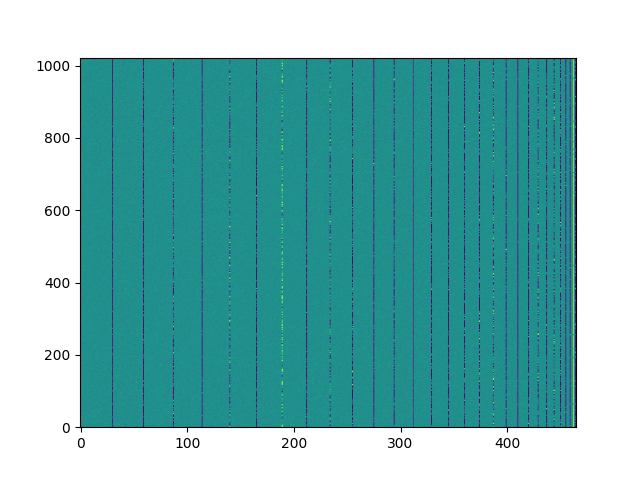

In [12]:
figure()
imshow(d[1:1024,chan,:,0], aspect='auto', origin='lower')

<IPython.core.display.Javascript object>


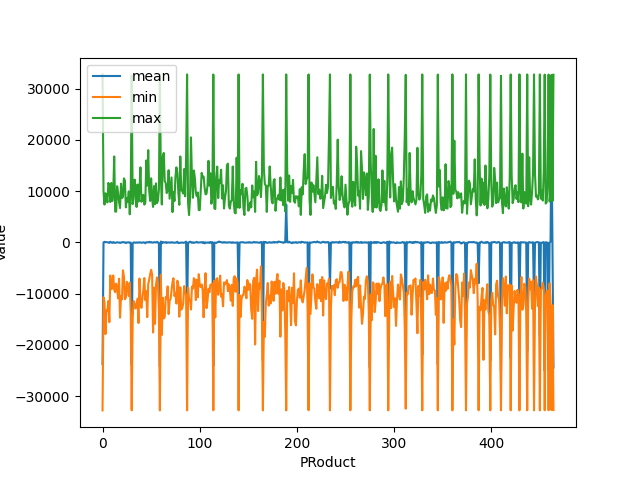

Text(0, 0.5, 'Value')

In [13]:
figure()
x = d[1:1024,chan,:,0]
plot(x.mean(axis=0), label='mean')
plot(x.min(axis=0), label='min')
plot(x.max(axis=0), label='max')
legend()
xlabel('PRoduct')
ylabel('Value')

<IPython.core.display.Javascript object>


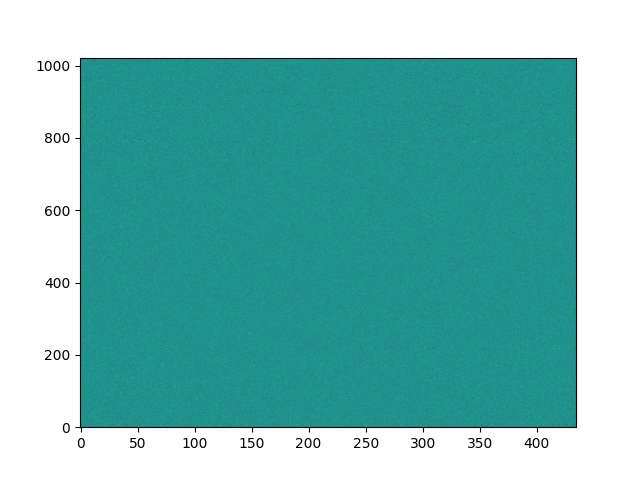

In [14]:
xc = d[1:1024,chan,cross_products,0]
figure()
imshow(xc, aspect='auto', origin='lower')

<IPython.core.display.Javascript object>


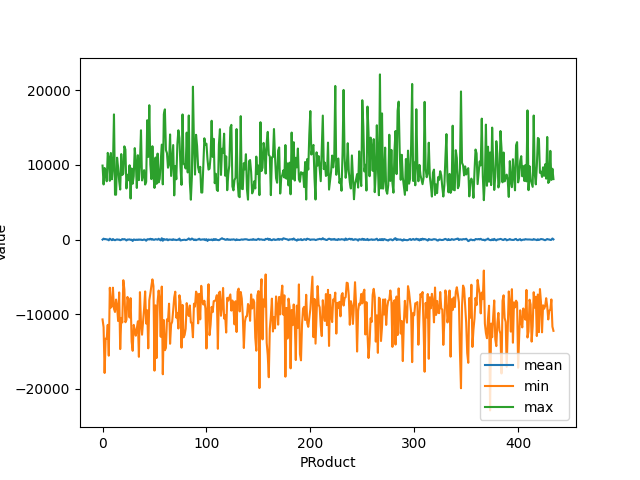

Text(0, 0.5, 'Value')

In [15]:
figure()
plot(xc.mean(axis=0), label='mean')
plot(xc.min(axis=0), label='min')
plot(xc.max(axis=0), label='max')
legend()
xlabel('PRoduct')
ylabel('Value')

In [16]:
xa = d[1:,...,0].astype(float)**2 + d[1:,...,1].astype(float)**2
xa.shape

(6399, 4, 465)

<IPython.core.display.Javascript object>


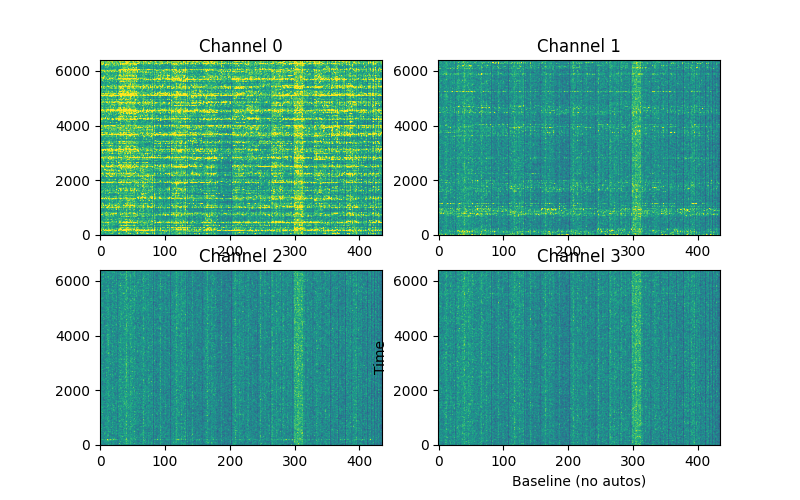

Text(0, 0.5, 'Time')

In [17]:
fig, axs = subplots(2,2)

fig.set_size_inches((8,5))
for ic in range(4):
    axs.flat[ic].imshow(xa[:,ic,cross_products], aspect='auto', origin='lower',vmax=1.5e7)
    axs.flat[ic].set_title(f'Channel {ic}')
xlabel('Baseline (no autos)')
ylabel('Time')


<IPython.core.display.Javascript object>


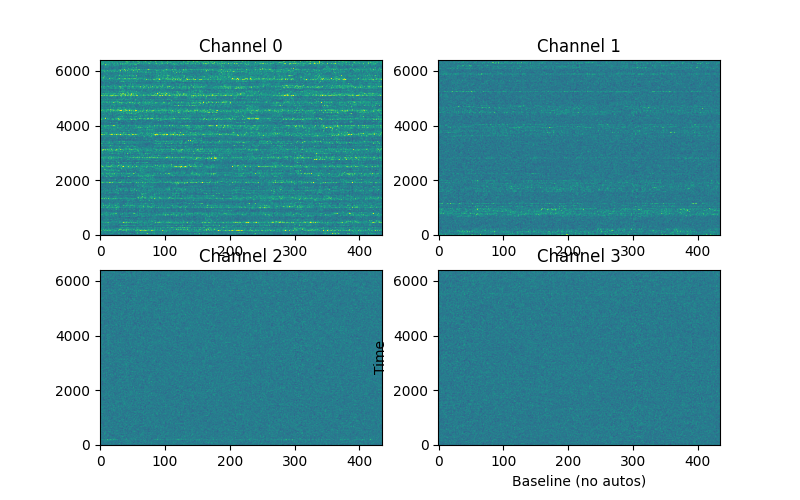

Text(0, 0.5, 'Time')

In [18]:
fig, axs = subplots(2,2)

fig.set_size_inches((8,5))
for ic in range(4):
    axs.flat[ic].imshow(xa[:,ic,cross_products] - xa[:,ic,cross_products].mean(axis=0), aspect='auto', origin='lower',vmax=1.5e7)
    axs.flat[ic].set_title(f'Channel {ic}')
xlabel('Baseline (no autos)')
ylabel('Time')

<IPython.core.display.Javascript object>


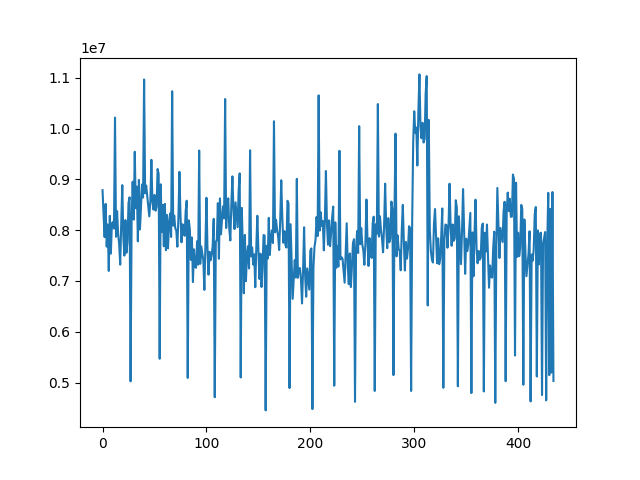

In [19]:
figure()
plot(xa[:,chan,cross_products].mean(axis=0))

<IPython.core.display.Javascript object>


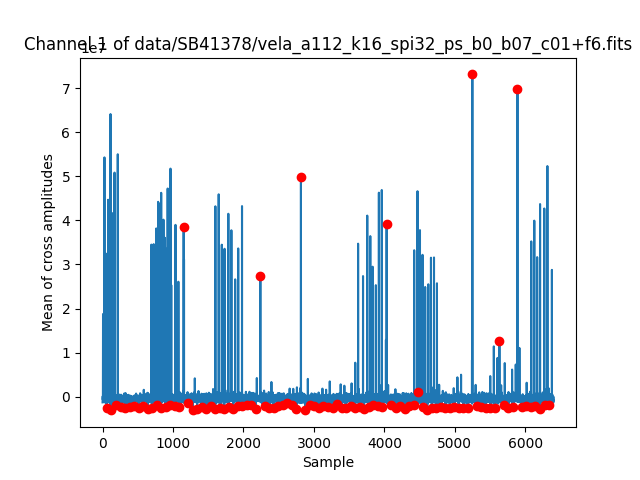

Text(0.5, 1.0, 'Channel 1 of data/SB41378/vela_a112_k16_spi32_ps_b0_b07_c01+f6.fits')

In [20]:
figure()
xac  = xa[:, chan, cross_products]
xam = (xac - xac.mean(axis=0)).mean(axis=1)
plot(xam)
plot(np.arange(len(xam))[63::64], xam[63::64], 'ro')
vela_phase = 40
vela_period = 52
#plot(np.arange(len(xam))[vela_phase::vela_period], xam[vela_phase::vela_period], 'gx')

xlabel('Sample')
ylabel('Mean of cross amplitudes')
title(f'Channel {chan} of {p.fname}')

<IPython.core.display.Javascript object>


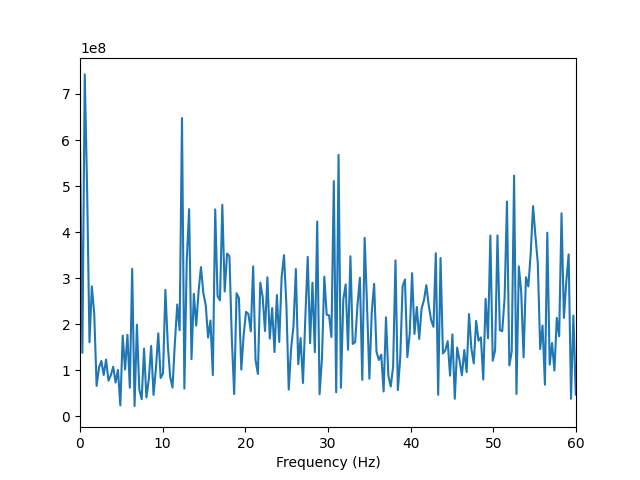

(0.0, 60.0)

In [21]:
figure()
xamf = abs(np.fft.rfft(xam[:2048]))
nf = len(xamf)
tsamp = 1.7e-3
fs = 1/tsamp
freqs = np.arange(nf)/nf*fs/2
plot(freqs, xamf)
xlabel('Frequency (Hz)')
xlim(0,60)

<IPython.core.display.Javascript object>


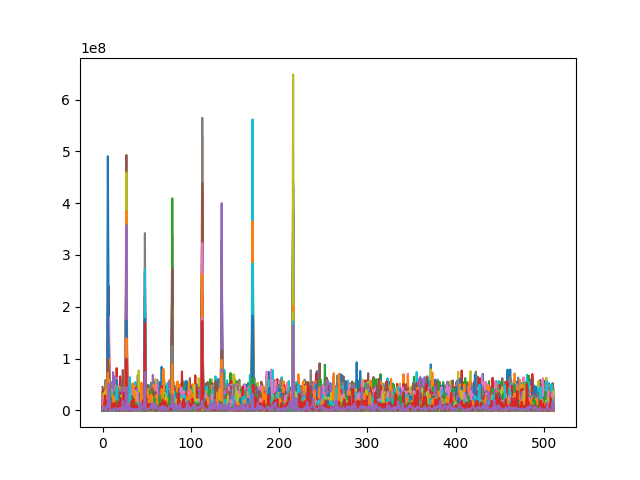

In [22]:
figure()
_ = plot(xa[:512,chan,cross_products])

<IPython.core.display.Javascript object>


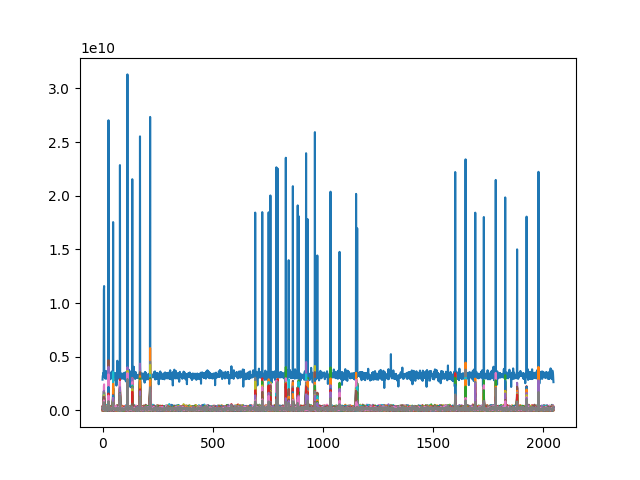

In [23]:
figure()
_ = plot(abs(np.fft.rfft(xa[:2048,chan,cross_products], axis=1)))

<IPython.core.display.Javascript object>


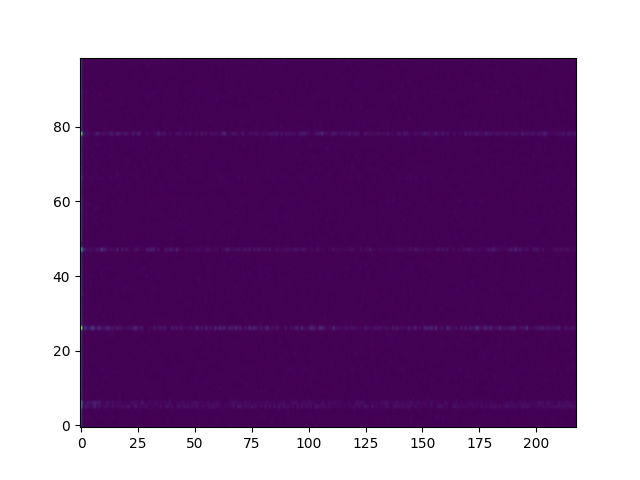

In [24]:
figure()
imshow(abs(np.fft.rfft(xa[:2048,chan,cross_products], axis=1)[1:100,:]), aspect='auto', origin='lower')